<a href="https://colab.research.google.com/github/devCat404/AI_Learning/blob/main/Supervised%20Learning/Regression/RidgeRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Supervised Learning: Regression</h1>

<h3>● Ridge Regression</h3>

Ridge Regression is an extension of Linear Regression that introduces L2 regularization to reduce overfitting and control the magnitude of the model parameters.

It assumes a linear relationship between the input and output, while adding a penalty term to the loss function that discourages large weights.

From a neural network perspective, Ridge Regression can be represented in the same way as Linear Regression, with the key difference being the addition of an L2 regularization term to the loss function.

<br>

<div align="center">

<img src="https://shreyanshhub.github.io/machine_learning__/img/ridge_solution.png" width="600">

</div>

<br>

The prediction is given by:

$$
\hat{y} = wx + b
$$

The loss function combines the Mean Squared Error (MSE) with an L2 regularization term:

$$
L =
\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2
+
\lambda\sum_{j}w_j^2
$$

where $\lambda$ controls the strength of the regularization.

The L2 penalty encourages the model to keep its weights small, which can improve generalization and reduce overfitting.

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np

<h3>● Import Libraries</h3>

The following libraries are imported for implementing, training, and visualizing the Ridge Regression model.

- <b>PyTorch</b> is used for tensor computation, automatic differentiation, and model training.
- <b>torch.nn</b> provides neural network modules such as <code>nn.Linear</code>.
- <b>torch.nn.functional</b> provides functions such as the Mean Squared Error (MSE) loss.
- <b>matplotlib.pyplot</b> is used to visualize the training process and regression results.
- <b>NumPy</b> is used for numerical computation and data manipulation.

In Ridge Regression, these libraries are used to construct the linear model and optimize its parameters while incorporating an L2 regularization term into the loss function.

In [26]:
class RidgeRegression(nn.Module):
  def __init__(self, n_features, lambda_reg):
    super(RidgeRegression, self).__init__()

    self.lambda_reg = lambda_reg
    self.linear = nn.Linear(n_features, 1)

  def forward(self, x):
    return self.linear(x)

<h3>● Define the Ridge Regression Model</h3>

Ridge Regression uses the same linear prediction structure as Linear Regression, but introduces an additional L2 regularization term to control the magnitude of the model weights.

The model is defined as:

$$
\hat{y} = \mathbf{w}^T\mathbf{x}+b
$$

<br>

<b>1. Model Class</b>

<code>RidgeRegression</code> inherits from <code>nn.Module</code>, which is the base class for PyTorch models.

The model receives two main parameters:

- <code>n_features</code> — the number of input features.
- <code>lambda_reg</code> — the strength of the L2 regularization.

<br>

<b>2. Linear Layer</b>

The linear layer is created using <code>nn.Linear</code>:

$$
\hat{y} = \mathbf{w}^T\mathbf{x}+b
$$

The weight $\mathbf{w}$ and bias $b$ are learnable parameters.

<br>

<b>3. Regularization Parameter</b>

The value of $\lambda$ determines how strongly large weights are penalized.

The Ridge Regression objective is:

$$
L =
\frac{1}{N}\sum_{i=1}^{N}
(\hat{y}_i-y_i)^2
+
\lambda\|\mathbf{w}\|_2^2
$$

where

$$
\|\mathbf{w}\|_2^2
=
\sum_{j=1}^{d}w_j^2
$$

A larger $\lambda$ applies stronger regularization and encourages smaller weights.

<br>

<b>4. Forward Propagation</b>

The <code>forward()</code> method passes the input through the linear layer:

$$
\mathbf{x}
\rightarrow
\mathbf{w}^T\mathbf{x}+b
\rightarrow
\hat{y}
$$

The important point is that <b>Ridge Regression does not change the prediction function itself</b>.

Both Linear Regression and Ridge Regression use:

$$
\boxed{\hat{y}=\mathbf{w}^T\mathbf{x}+b}
$$

The difference is in the <b>objective function</b> used during training:

$$
\boxed{
\text{Linear Regression: MSE}
}
$$

$$
\boxed{
\text{Ridge Regression: MSE}+\lambda\|\mathbf{w}\|_2^2
}
$$

Therefore, Ridge Regression can be understood as Linear Regression with an additional constraint that discourages excessively large weights.

In [27]:
def ridge_loss(model, outputs, targets):
    mse_loss = F.mse_loss(outputs, targets)
    l2_reg = torch.tensor(0., requires_grad=True)
    for name, param in model.named_parameters():
        if 'linear.weight' in name:
            l2_reg = l2_reg + torch.norm(param, p=2)

    return mse_loss + model.lambda_reg * l2_reg

<h3>● Ridge Loss Function</h3>

Ridge Regression extends the Mean Squared Error (MSE) loss by adding an L2 regularization term.

The objective function is:

$$
L =
\frac{1}{N}\sum_{i=1}^{N}
(\hat{y}_i-y_i)^2
+
\lambda\|\mathbf{w}\|_2^2
$$

where:

- $L$ is the total loss.
- The first term is the MSE loss.
- $\mathbf{w}$ represents the model weights.
- $\lambda$ controls the strength of the regularization.
- The bias $b$ is not included in the regularization term.

<br>

<b>1. MSE Loss</b>

The first part measures how well the model fits the training data:

$$
L_{\text{MSE}}
=
\frac{1}{N}\sum_{i=1}^{N}
(\hat{y}_i-y_i)^2
$$

A smaller MSE means that the predictions are closer to the true target values.

<br>

<b>2. L2 Regularization</b>

The second part penalizes large weights:

$$
L_{\text{reg}}
=
\lambda\|\mathbf{w}\|_2^2
$$

The L2 norm is based on the magnitude of the weight vector:

$$
\|\mathbf{w}\|_2
=
\sqrt{\sum_j w_j^2}
$$

Therefore, the regularization term encourages the model to keep its weights small.

<br>

<b>3. Total Ridge Loss</b>

The two components are combined:

$$
\boxed{
L_{\text{Ridge}}
=
L_{\text{MSE}}
+
\lambda L_{\text{reg}}
}
$$

The model therefore has to balance two objectives:

$$
\text{Good data fitting}
\quad+\quad
\text{Small weights}
$$

A larger $\lambda$ places more importance on keeping the weights small, while a smaller $\lambda$ allows the model to focus more on fitting the training data.

<br>

<b>4. Why is the Bias Excluded?</b>

Only the model weights are regularized:

$$
\lambda\|\mathbf{w}\|_2^2
$$

and not the bias:

$$
\lambda\|\mathbf{w}\|_2^2
\neq
\lambda(\|\mathbf{w}\|_2^2+b^2)
$$

The bias determines the vertical position of the regression function, while the weights determine how strongly the input features affect the prediction.

Therefore, Ridge Regression typically applies regularization to the weights but not to the bias.

<br>

<b>5. Important Implementation Detail</b>

The code identifies <code>linear.weight</code> through <code>model.named_parameters()</code> and applies the regularization only to this parameter.

Conceptually, the implementation performs:

$$
\text{Total Loss}
=
\underbrace{\text{MSE}}_{\text{data fitting}}
+
\underbrace{\lambda\|\mathbf{w}\|_2}_{\text{regularization}}
$$

However, there is an important mathematical detail: standard Ridge Regression usually uses the <b>squared L2 norm</b>,

$$
\|\mathbf{w}\|_2^2
=
\sum_j w_j^2
$$

whereas <code>torch.norm(param, p=2)</code> calculates the ordinary L2 norm:

$$
\|\mathbf{w}\|_2
=
\sqrt{\sum_j w_j^2}
$$

Therefore, if the goal is to implement the standard Ridge Regression objective exactly, the regularization term should correspond to:

$$
\boxed{
L_{\text{Ridge}}
=
L_{\text{MSE}}
+
\lambda\sum_j w_j^2
}
$$

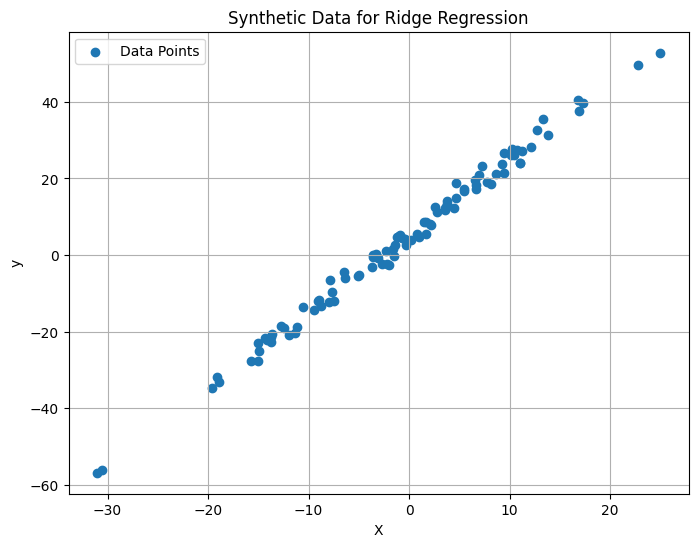

In [28]:
n_samples = 100
n_features = 1

X = torch.randn(n_samples, n_features) * 10
y = 2 * X + 5 + torch.randn(n_samples, n_features) * 2

plt.figure(figsize=(8, 6))
plt.scatter(X.numpy(), y.numpy(), label='Data Points')
plt.title('Synthetic Data for Ridge Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

<h3>● Generate Synthetic Data</h3>

To demonstrate Ridge Regression, we first generate a synthetic dataset with a known linear relationship.

<br>

<b>1. Number of Samples and Features</b>

The dataset contains 100 samples and 1 input feature:

$$
N=100
$$

$$
d=1
$$

where $N$ is the number of samples and $d$ is the number of input features.

<br>

<b>2. Generate Input Data</b>

The input values are sampled from a standard normal distribution and scaled by 10:

$$
X\sim\mathcal{N}(0,1)\times10
$$

This creates a range of input values with a larger spread.

<br>

<b>3. Generate Target Values</b>

The target variable is generated according to the following relationship:

$$
y=2X+5+\epsilon
$$

where the noise term is:

$$
\epsilon\sim\mathcal{N}(0,2^2)
$$

Therefore, the underlying relationship between $X$ and $y$ is approximately:

$$
\boxed{y=2X+5}
$$

The noise is added to make the dataset more realistic and prevent all points from lying exactly on a single line.

<br>

<b>4. Expected Regression Parameters</b>

Since the data was generated using:

$$
y=2X+5+\epsilon
$$

the ideal underlying parameters are:

$$
w=2
$$

$$
b=5
$$

The purpose of Ridge Regression is to estimate these parameters from the noisy observations while controlling the magnitude of the weight through L2 regularization.

<br>

<b>5. Visualize the Dataset</b>

The scatter plot displays the generated observations.

Because random noise is added to the target values, the points should form a cloud around the underlying linear relationship:

$$
y=2X+5
$$

The scatter plot therefore provides a visual representation of the regression problem before the Ridge Regression model is trained.

In [32]:
lambda_reg = 0.1
model = RidgeRegression(n_features=n_features, lambda_reg=lambda_reg)

learning_rate = 0.001
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

print(f"Ridge Regression Model initialized with lambda_reg={lambda_reg}")
print(f"Optimizer: SGD with learning_rate={learning_rate}")

Ridge Regression Model initialized with lambda_reg=0.1
Optimizer: SGD with learning_rate=0.001


<h3>● Initialize the Ridge Regression Model</h3>

Before training, we initialize the Ridge Regression model and define the regularization strength and learning rate.

<br>

<b>1. Regularization Strength</b>

The regularization parameter is set to:

$$
\lambda=0.1
$$

The value of $\lambda$ determines how strongly the model penalizes large weights.

The Ridge Regression objective function is:

$$
L=
\text{MSE}
+
\lambda\|\mathbf{w}\|_2^2
$$

A larger $\lambda$ results in stronger regularization and generally produces smaller model weights.

<br>

<b>2. Model Initialization</b>

The Ridge Regression model is initialized with the number of input features and the chosen regularization strength.

Since the synthetic dataset contains one feature:

$$
n_{\text{features}}=1
$$

the model learns one weight and one bias:

$$
\hat{y}=wx+b
$$

<br>

<b>3. Optimizer</b>

Stochastic Gradient Descent (SGD) is used to optimize the model parameters.

The learning rate is set to:

$$
\eta=0.001
$$

The parameters are updated according to:

$$
\theta
\leftarrow
\theta
-
\eta
\frac{\partial L}{\partial\theta}
$$

where $\theta$ represents the learnable parameters $w$ and $b$.

<br>

<b>4. Training Configuration</b>

The current configuration is therefore:

$$
\boxed{\lambda=0.1}
$$

$$
\boxed{\eta=0.001}
$$

$$
\boxed{\text{Optimizer}=\text{SGD}}
$$

The model will now learn $w$ and $b$ by minimizing the Ridge Regression loss, which balances data fitting and weight regularization.

In [33]:
def ridge_loss(model, outputs, targets):
    mse_loss = F.mse_loss(outputs, targets)
    l2_reg = torch.tensor(0., requires_grad=True)
    for name, param in model.named_parameters():
        if 'linear.weight' in name:
            l2_reg = l2_reg + torch.norm(param, p=2)

    return mse_loss + model.lambda_reg * l2_reg

n_epochs = 1000
loss_history = []

for epoch in range(n_epochs):
    outputs = model(X)

    loss = ridge_loss(model, outputs, y)
    loss_history.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 25.9899
Epoch [200/1000], Loss: 18.5333
Epoch [300/1000], Loss: 13.5262
Epoch [400/1000], Loss: 10.1640
Epoch [500/1000], Loss: 7.9064
Epoch [600/1000], Loss: 6.3904
Epoch [700/1000], Loss: 5.3724
Epoch [800/1000], Loss: 4.6888
Epoch [900/1000], Loss: 4.2298
Epoch [1000/1000], Loss: 3.9216


<h3>● Train the Ridge Regression Model</h3>

The Ridge Regression model is trained for 1,000 epochs using the Ridge loss function and SGD optimizer.

<br>

<b>1. Ridge Loss</b>

For each epoch, the model first generates predictions:

$$
\hat{y}=wx+b
$$

The loss is then calculated by combining the MSE and the L2 regularization term:

$$
L_{\text{Ridge}}
=
L_{\text{MSE}}
+
\lambda\|\mathbf{w}\|_2
$$

In this implementation, the regularization strength is:

$$
\lambda=0.1
$$

<br>

<b>2. Parameter Update</b>

After calculating the loss, backpropagation computes the gradients:

$$
\frac{\partial L}{\partial w},
\qquad
\frac{\partial L}{\partial b}
$$

The SGD optimizer then updates the parameters:

$$
\theta
\leftarrow
\theta
-
\eta
\frac{\partial L}{\partial\theta}
$$

where the learning rate is:

$$
\eta=0.001
$$

This process is repeated for 1,000 epochs.

<br>

<b>3. Training Results</b>

The loss decreases throughout the training process:

$$
L_{100}=25.9899
$$

$$
L_{200}=18.5333
$$

$$
L_{300}=13.5262
$$

$$
L_{400}=10.1640
$$

$$
L_{500}=7.9064
$$

$$
L_{600}=6.3904
$$

$$
L_{700}=5.3724
$$

$$
L_{800}=4.6888
$$

$$
L_{900}=4.2298
$$

$$
L_{1000}=3.9216
$$

<br>

<b>4. Interpretation</b>

The continuous decrease in loss indicates that the model is successfully learning from the synthetic data.

The loss decreases rapidly during the early stages of training and then gradually becomes smaller:

$$
25.9899
\rightarrow
18.5333
\rightarrow
\cdots
\rightarrow
3.9216
$$

This pattern indicates that the model is approaching a minimum of the Ridge loss function.

The decrease becomes progressively slower as training continues, which is typical of gradient-based optimization near a minimum.

<br>

<b>5. Important Point About Ridge Regression</b>

The model is not minimizing the MSE alone.

Instead, it minimizes:

$$
\boxed{
L_{\text{Ridge}}
=
\underbrace{
\frac{1}{N}\sum_{i=1}^{N}
(\hat{y}_i-y_i)^2
}_{\text{Data fitting}}
+
\underbrace{
\lambda\|\mathbf{w}\|_2
}_{\text{Weight penalty}}
}
$$

Therefore, the optimizer searches for parameters that provide a good fit to the data while also preventing the weight from becoming unnecessarily large.

<br>

<b>6. Training Progress</b>

The overall optimization process can be summarized as:

$$
(w,b)_{\text{initial}}
\rightarrow
\text{Prediction}
\rightarrow
\text{Ridge Loss}
\rightarrow
\text{Gradient Calculation}
\rightarrow
\text{SGD Update}
\rightarrow
(w,b)_{\text{new}}
$$

This process is repeated 1,000 times, resulting in the observed decrease in Ridge loss from approximately $25.99$ to $3.92$.

<br>

<b>Note</b>

The current implementation uses the L2 norm:

$$
\|\mathbf{w}\|_2
=
\sqrt{\sum_j w_j^2}
$$

rather than the squared L2 norm normally used in standard Ridge Regression:

$$
\|\mathbf{w}\|_2^2
=
\sum_j w_j^2
$$

Therefore, mathematically, this implementation is slightly different from the conventional Ridge objective.

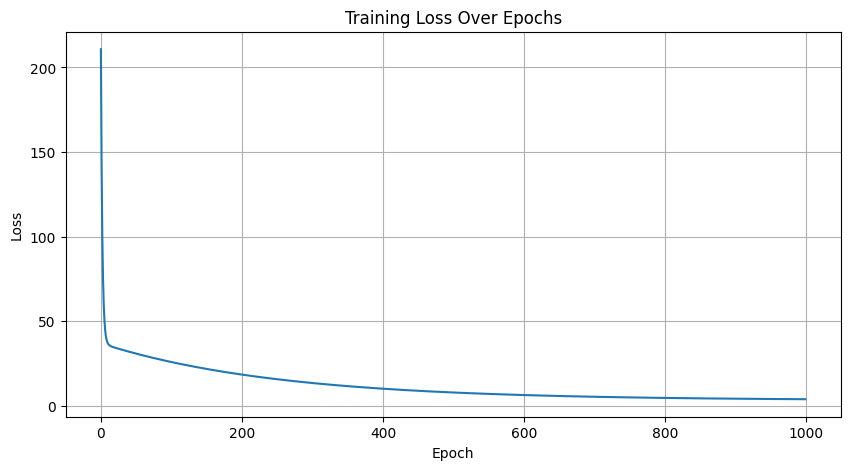

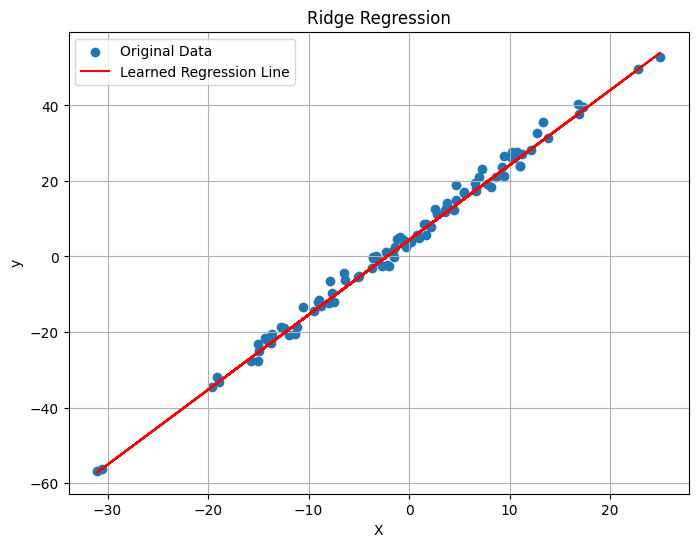

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

predicted_y = model(X).detach().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(X.numpy(), y.numpy(), label='Original Data')
plt.plot(X.numpy(), predicted_y, color='red', label='Learned Regression Line')
plt.title('Ridge Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

<h3>● Visualize the Training Process and Regression Result</h3>

After training the Ridge Regression model, two plots are used to evaluate the learning process and the final regression result.

<br>

<b>1. Training Loss Curve</b>

The loss recorded at each epoch is plotted to observe how the Ridge Regression model learns during training.

The x-axis represents the training epoch, while the y-axis represents the Ridge loss:

$$
L_{\text{Ridge}}
=
L_{\text{MSE}}
+
\lambda\|\mathbf{w}\|_2
$$

As training progresses, the loss should generally decrease:

$$
L_1 > L_2 > \cdots > L_{1000}
$$

For this experiment, the loss decreased from approximately $25.99$ at epoch 100 to $3.92$ at epoch 1000.

This indicates that the model is continuously improving its parameters to minimize the Ridge objective.

<br>

<b>2. Learned Regression Line</b>

After training, the model generates predictions for all input values:

$$
\hat{y}=wx+b
$$

The predicted values are then plotted together with the original data points.

The scatter points represent the noisy synthetic observations, while the regression line represents the relationship learned by the Ridge Regression model.

The underlying relationship used to generate the synthetic data was:

$$
y=2x+5+\epsilon
$$

Therefore, the ideal regression relationship before adding noise is:

$$
y=2x+5
$$

The learned Ridge Regression line should lie close to this underlying relationship.

<br>

<b>3. Interpretation</b>

The two plots provide different information about the model:

<ul>
<li><b>Training Loss Curve:</b> Shows whether the optimization process is converging.</li>
<li><b>Regression Plot:</b> Shows how well the learned model represents the relationship between $X$ and $y$.</li>
</ul>

Together, they allow us to evaluate both the <b>optimization process</b> and the <b>final regression fit</b>.

<br>

<b>Overall</b>

$$
\boxed{
\text{Training Loss}
\rightarrow
\text{Parameter Optimization}
\rightarrow
\text{Learned Regression Line}
}
$$

The first plot answers <i>"Is the model learning?"</i>, while the second plot answers <i>"What relationship did the model learn?"</i>.